In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_excel(r"C:\Users\theep\Documents\CS External\Found Project\2024_2025.xlsx", sheet_name = 'rawData', header=None)
df = df.iloc[6:737].reset_index(drop=True)

In [4]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,2024-01-01 00:00:00,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01-02 00:00:00,Tu,94.75,225.35,NaN,320.1,109,2.936697,1.005655,NaN,...,2.920183,1,NaN,1.8,NaN,0,0.005655,NaN,NaN,NaN
2,2024-01-03 00:00:00,W,92.1,195,NaN,287.1,83,3.459036,1,NaN,...,3.459036,1,NaN,0,NaN,0,0,NaN,NaN,NaN
3,2024-01-04 00:00:00,Th,177.7,258.4,NaN,436.1,125,3.4888,0.983204,NaN,...,3.5484,1,NaN,-7.45,NaN,0,-0.016796,NaN,NaN,NaN
4,2024-01-05 00:00:00,F,101.61,243.42,NaN,345.03,98,3.520714,1.012204,NaN,...,3.478265,1,NaN,4.16,NaN,0,0.012204,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,2025-12-27 00:00:00,Sa,NaN,NaN,NaN,0,0,0,0,NaN,...,0,0,NaN,0,NaN,0,0,NaN,NaN,NaN
727,2025-12-28 00:00:00,Su,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
728,2025-12-29 00:00:00,M,147.81,311.17,2,460.98,108,4.268333,1.003177,NaN,...,4.254815,1,NaN,1.46,NaN,0,0.003177,NaN,NaN,NaN
729,2025-12-30 00:00:00,Tu,108.15,274.5,NaN,382.65,108,3.543056,0.987102,NaN,...,3.589352,1,NaN,-5,NaN,0,-0.012898,NaN,NaN,NaN


In [5]:
categories = {
    "drinks": 13, "books": 18, "media": 23, "bric_a_brac": 28, "toys": 33,
    "jewellery": 38, "linen": 43, "anything_else": 48, "womens": 53,
    "mens": 58, "childrens": 63, "footwear": 68, "electricals": 73, "food": 78
}
#this dictionary makes it easier in the long run to select specfic columns in the excel 
#table and create a clean table to perform EDA
#- it corresponds to the excel sheeT, e.g. Drinks is column N which is the 14th letter form the alphabet
# - but in pandas it starts with 0 so A= 0 an therfore N = 14-1 = 13 so drinks is 13 in the dictionary

clean = pd.DataFrame({
    "date": pd.to_datetime(df[0], errors="coerce"),
    "day": df[1],
    "total_sales": pd.to_numeric(df[5], errors="coerce"),
    "total_units": pd.to_numeric(df[6], errors="coerce"),
    "guests": pd.to_numeric(df[10], errors="coerce"),
})


for name, col in categories.items():
    clean[f"{name}_sales"] = pd.to_numeric(df[col], errors="coerce")
    clean[f"{name}_units"] = pd.to_numeric(df[col+1], errors="coerce")



clean = clean.dropna(subset=["date"])

In [6]:
clean = clean.dropna(subset=["date"])


In [7]:
clean["closed"] = clean["total_sales"].isna()


In [8]:
long_df = clean.melt(
    id_vars=["date", "day", "total_sales", "guests"], 
    value_vars=[c for c in clean.columns if c.endswith("_sales")],
    var_name="category", value_name="category_sales" 
)


In [9]:
long_df["category"] = long_df["category"].str.replace("_sales", "")
# just replaces drink_sales with drinks as the sales bit is not necessary now

In [10]:
print(long_df.head())

        date day  total_sales  guests category  category_sales
0 2024-01-01   M          NaN     NaN   drinks             NaN
1 2024-01-02  Tu       320.10    48.0   drinks             0.0
2 2024-01-03   W       287.10    42.0   drinks             0.0
3 2024-01-04  Th       436.10    60.0   drinks             1.5
4 2024-01-05   F       345.03    47.0   drinks             0.0


In [11]:
clean['month'] = clean["date"].dt.to_period("M")
clean['week'] = clean["date"].dt.to_period("W")

In [12]:
#Finding peak months
monthly_sales = clean.groupby('month')["total_sales"].sum().sort_values(ascending=False)


In [13]:
print(clean.head())

        date day  total_sales  total_units  guests  drinks_sales  \
0 2024-01-01   M          NaN          NaN     NaN           NaN   
1 2024-01-02  Tu       320.10        109.0    48.0           0.0   
2 2024-01-03   W       287.10         83.0    42.0           0.0   
3 2024-01-04  Th       436.10        125.0    60.0           1.5   
4 2024-01-05   F       345.03         98.0    47.0           0.0   

   drinks_units  books_sales  books_units  media_sales  ...  childrens_units  \
0           NaN          NaN          NaN          NaN  ...              NaN   
1           0.0          8.8         10.0          3.0  ...              2.0   
2           0.0         18.5          8.0         10.5  ...              3.0   
3           1.0         20.0          8.0          0.0  ...              6.0   
4           0.0          9.9          9.0          0.0  ...              2.0   

   footwear_sales  footwear_units  electricals_sales  electricals_units  \
0             NaN             NaN  

In [14]:
print(monthly_sales)

month
2024-10    13472.16
2024-11    13134.24
2025-11    12298.02
2024-05    12256.89
2025-10    11576.51
2025-01    11551.19
2024-12    11520.67
2025-09    11209.02
2024-04    11104.63
2025-07    10906.88
2025-12    10905.49
2025-06    10674.11
2024-06    10648.89
2024-07    10648.11
2025-03    10636.17
2025-04    10438.48
2024-09    10386.75
2024-03    10333.31
2025-05    10126.77
2024-02    10117.16
2024-01     9726.19
2025-02     9618.52
2025-08     9449.34
2024-08     8521.41
Freq: M, Name: total_sales, dtype: float64


In [15]:
#category by month heatmap table
cat_by_month = long_df.groupby([long_df["date"].dt.to_period("M"),"category"])["category_sales"].sum().unstack()

<Axes: xlabel='date', ylabel='category'>

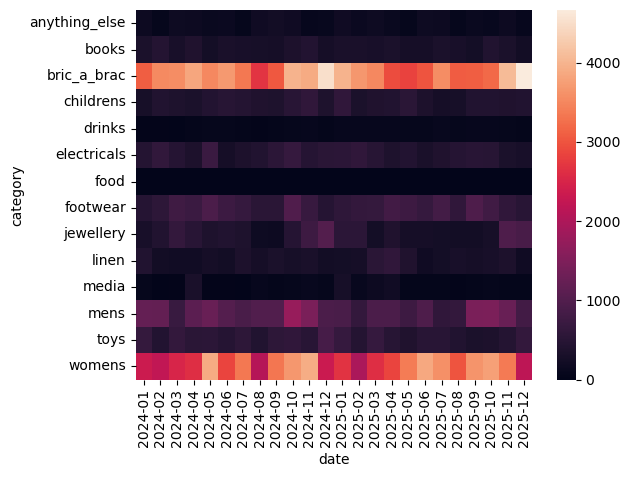

In [16]:
import seaborn as sns
sns.heatmap(cat_by_month.T)

In [17]:
#Guests vs. Sales
clean['spend_per_guest'] = clean['total_sales']/clean['guests']

In [18]:
monthly = clean.groupby('month').agg(guests=('guests','sum'), sales=('total_sales', 'sum'))

In [19]:
monthly['spend_per_guest'] = monthly['sales']/monthly['guests']

In [20]:
print(monthly['spend_per_guest'])

month
2024-01    7.737621
2024-02    8.368205
2024-03    8.554065
2024-04    8.548599
2024-05    8.499924
2024-06    8.030837
2024-07    7.946351
2024-08    7.963935
2024-09    7.543028
2024-10    8.669344
2024-11    8.886495
2024-12    9.746760
2025-01    9.124163
2025-02    8.015433
2025-03    8.303021
2025-04    8.370874
2025-05    7.856299
2025-06    7.947960
2025-07    8.091157
2025-08    7.446288
2025-09    8.530457
2025-10    8.175501
2025-11    9.212000
2025-12    8.493372
Freq: M, Name: spend_per_guest, dtype: float64


In [21]:
from prophet import Prophet

In [22]:
ts = clean.groupby("date")["total_sales"].sum().reset_index() 
ts.columns = ['ds', 'y'] #strict prophet requirements or naming of date and sales column


In [23]:
m = Prophet(weekly_seasonality=True, yearly_seasonality=True)


In [24]:
m.fit(ts)


12:04:50 - cmdstanpy - INFO - Chain [1] start processing
12:04:51 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future = m.make_future_dataframe(periods=56)

In [26]:
forecast = m.predict(future)

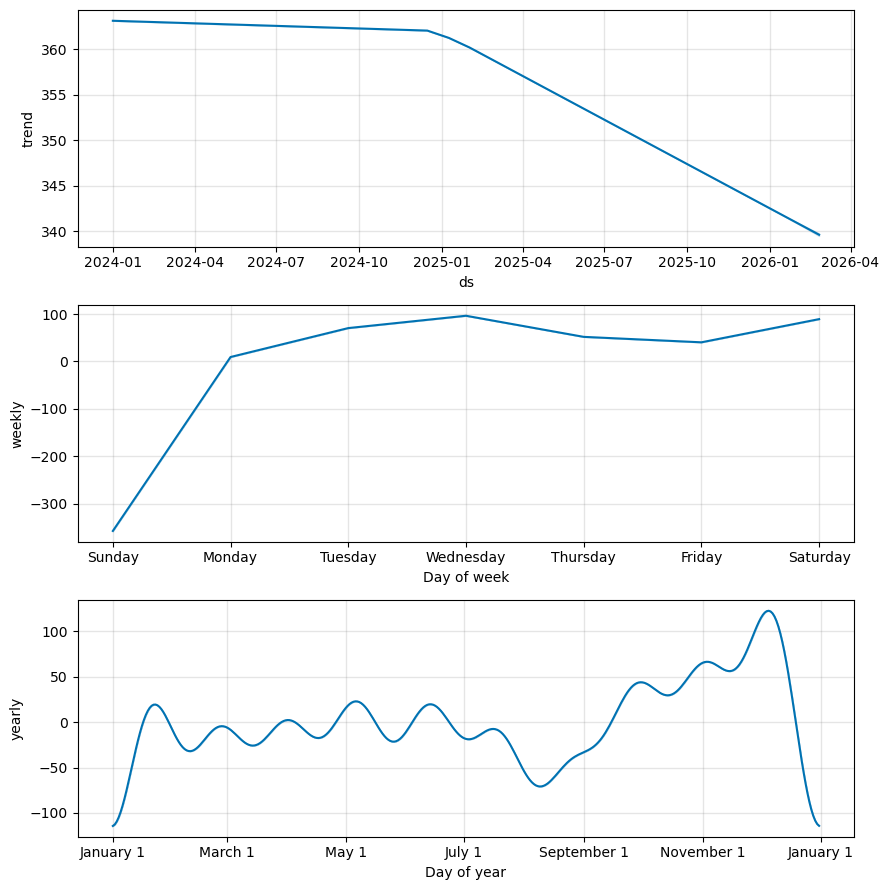

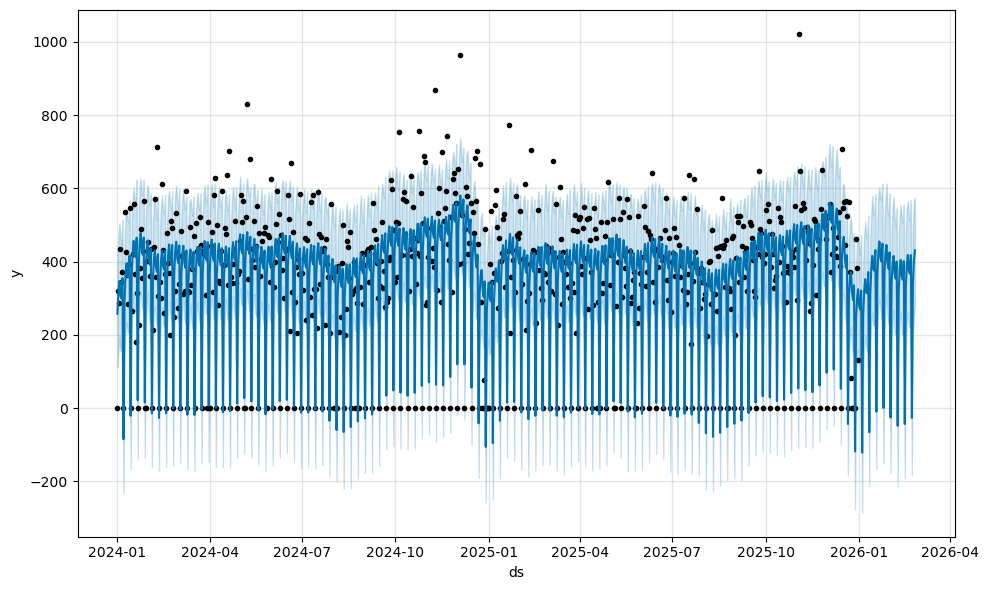

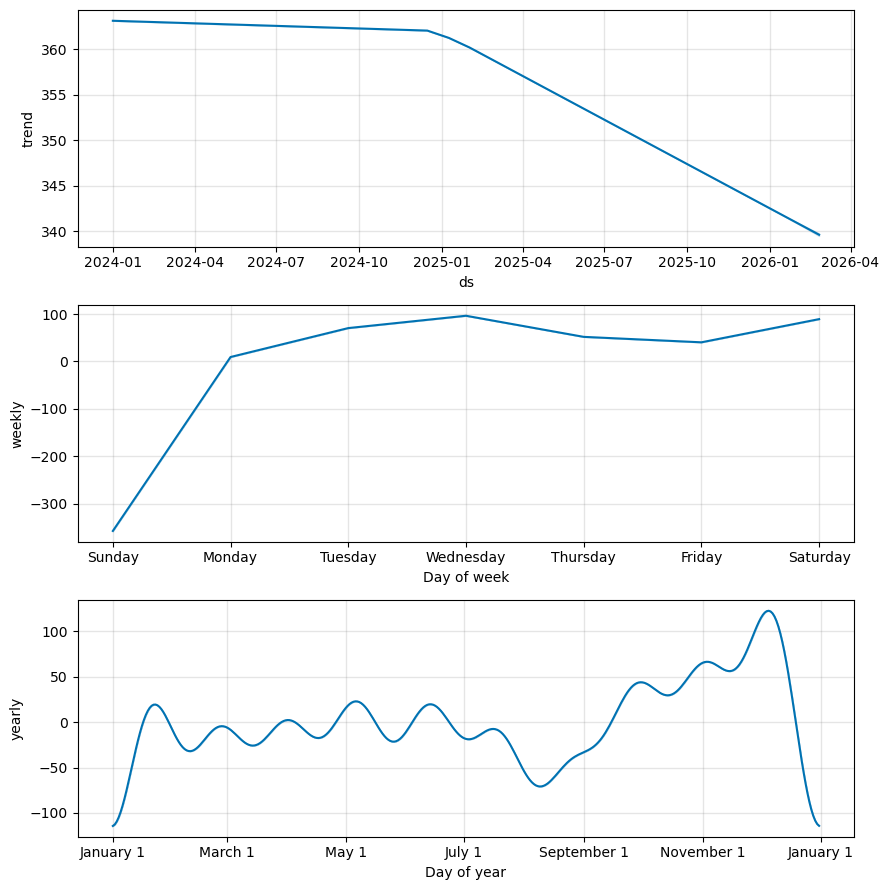

In [27]:
m.plot(forecast)
m.plot_components(forecast)

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [29]:
month_cat = cat_by_month.fillna(0)
# take the month by category in EDA and replace all missing values with 0

In [30]:
scaled = StandardScaler().fit_transform(month_cat)

In [31]:
km = KMeans(n_clusters=3, random_state=42, n_init=10) # run process 10 diff times with diff random starting points)


In [32]:
month_cat["cluster"] = km.fit_predict(scaled)


C:\Users\theep\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [33]:
month_cat.groupby("cluster").mean()


category,anything_else,books,bric_a_brac,childrens,drinks,electricals,food,footwear,jewellery,linen,media,mens,toys,womens
cluster,,,,,,,,,,,,,,
0,140.274375,317.485000,3330.618750,392.145625,57.604375,441.38375,2.4275,653.42375,355.043125,311.97875,94.423125,901.038125,517.160000,2827.45625
1,119.588000,339.130000,3533.010000,471.002000,77.448000,565.66800,3.1780,866.20400,416.014000,285.87000,55.322000,1471.966000,462.226000,3767.01200
2,111.756667,276.566667,4415.943333,391.430000,49.366667,387.10000,0.6000,513.10000,948.366667,260.55000,50.233333,991.893333,645.433333,2621.51000


In [34]:
#Regression: does guest count actually predict sales?
import statsmodels.formula.api as smf

In [35]:
reg_df = clean.dropna(subset=["total_sales","guests"]).copy()


In [36]:
reg_df["month_num"] = reg_df["date"].dt.month 
reg_df["dow"] = reg_df["date"].dt.day_name() 

In [37]:
model = smf.ols("total_sales ~ guests + C(dow) + C(month_num)", data=reg_df).fit()


In [38]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_sales   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     44.98
Date:                Tue, 29 Sep 2026   Prob (F-statistic):           3.75e-98
Time:                        12:05:01   Log-Likelihood:                -3545.5
No. Observations:                 610   AIC:                             7129.
Df Residuals:                     591   BIC:                             7213.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.9517    

In [39]:
print(ts.sort_values("y", ascending=False).head(10))
print(ts["ds"].duplicated().sum())

            ds        y
672 2025-11-03  1021.99
338 2024-12-04   964.09
313 2024-11-09   868.80
128 2024-05-08   830.67
386 2025-01-21   772.57
297 2024-10-24   756.75
278 2024-10-05   755.10
325 2024-11-21   744.52
39  2024-02-09   712.30
714 2025-12-15   708.70
0
